# 20. Seismic Q: Earth's Attenuation Without a Viscosity

Seismic Earth models give the loss as quality factors, not viscosities. PREM tabulates the shear quality factor $Q_\mu$ (600 in the crust and lid, 80 in the low-velocity zone, 143 down to 670 km, 312 in the lower mantle, 84.6 in the inner core) and the bulk one $Q_\kappa$, all at its 1 s reference period. TidalPy can use them directly, with no viscosity inverted from them and no viscoelastic model assumed.

* The `seismic_q` rheology builds a complex modulus from a static modulus and a quality factor measured at a reference frequency.
* A world built from a radial data file sets `q_provided = true` to give each solid layer that rheology, fed by the file's `q_mu` and `q_kappa` columns. The reference frequency and how $Q$ scales with frequency are set in the world's TOML.
* The bundled `PREM.csv` now carries PREM's quality factors, and the bundled `earth_prem_q` world uses them.

This notebook:

1. shows the model: the loss and the dispersion it carries from 1 s to tidal periods;
2. plots PREM's quality factors;
3. compares PREM with and without its attenuation, at 1 s and at tidal periods;
4. asks how $Q$ must scale with frequency for PREM to reproduce Earth's measured M2 body-tide lag;
5. sets the scaling layer by layer.

In [1]:
%matplotlib inline
import copy
import math

import numpy as np
import matplotlib.pyplot as plt

from TidalPy.constants import G
from TidalPy.Rheology import seismic_q
from TidalPy.Structures import build_world
from TidalPy.Structures.configs import data_file, worldpack

HOUR, DAY, YEAR = 3600.0, 86400.0, 365.25 * 86400.0
PREM_REFERENCE = 2.0 * math.pi                     # PREM's 1 s reference period [rad/s]
M2 = 2.0 * math.pi / (12.4206012 * HOUR)           # principal lunar semidiurnal tide [rad/s]

## The Model

`seismic_q` reads its viscosity input as $Q_\mathrm{ref}$, the quality factor at the reference frequency $\omega_\mathrm{ref}$, where the modulus $\mu$ was measured too. With $s = \omega_\mathrm{ref}/\omega$ and an exponent $a$ in $[0, 1)$:

$$Q(\omega) = Q_\mathrm{ref}\,s^{-a}, \qquad \mathrm{Re}[\mu^{*}] = \frac{\mu}{1 + D(s)/Q_\mathrm{ref}}, \qquad \mathrm{Im}[\mu^{*}] = \frac{\mathrm{Re}[\mu^{*}]}{Q(\omega)},$$

$$D(s) = \cot\frac{\pi a}{2}\left(s^{a} - 1\right) \;\to\; \frac{2}{\pi}\ln s \quad (a = 0).$$

The loss is what the data give. $D$ is the dispersion causality requires of it: a material that dissipates cannot have a modulus that stays the same at every frequency. A constant $Q$ ($a = 0$) softens the modulus logarithmically toward long periods (Kanamori and Anderson 1977). A $Q$ that falls toward long periods as $\omega^{a}$ softens it faster (Wahr and Bergen 1986), as an absorption band does. Below, $Q_\mathrm{ref} = 143$, PREM's upper mantle, from 1 s to 3 years.

At M2, relative to 1 s:
  a = 0.0:  Re[mu*] / mu = 0.9545   Q =  143.0
  a = 0.1:  Re[mu*] / mu = 0.9219   Q =   49.0
  a = 0.2:  Re[mu*] / mu = 0.8608   Q =   16.8
  a = 0.3:  Re[mu*] / mu = 0.7535   Q =    5.8


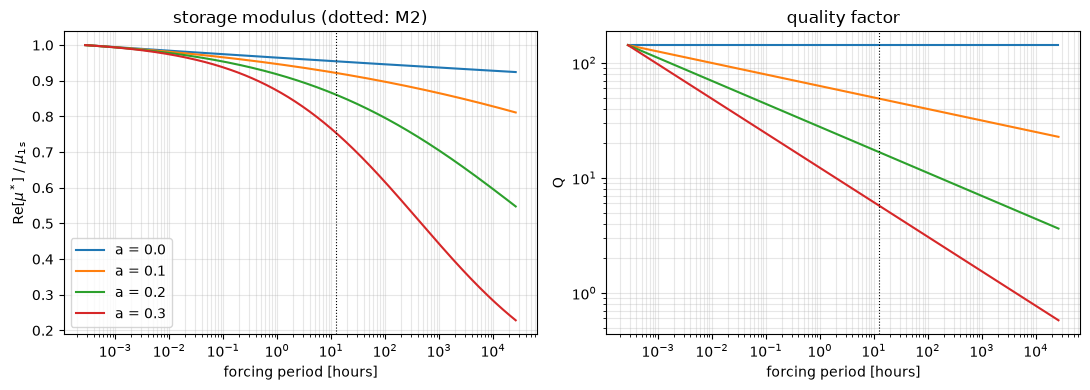

In [2]:
q_ref = 143.0
periods = np.logspace(0.0, math.log10(3.0 * YEAR), 300)
frequencies = 2.0 * math.pi / periods
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for exponent in (0.0, 0.1, 0.2, 0.3):
    modulus = seismic_q(1.0, q_ref, frequencies, q_frequency_exponent=exponent)
    axes[0].semilogx(periods / HOUR, modulus.real, label=f"a = {exponent}")
    axes[1].loglog(periods / HOUR, modulus.real / modulus.imag, label=f"a = {exponent}")
for ax in axes:
    ax.axvline(12.4206012, color="k", lw=0.8, ls=":")
    ax.set_xlabel("forcing period [hours]")
    ax.grid(True, which="both", alpha=0.3)
axes[0].set_ylabel(r"Re[$\mu^*$] / $\mu_\mathrm{1\,s}$")
axes[1].set_ylabel("Q")
axes[0].legend()
axes[0].set_title("storage modulus (dotted: M2)")
axes[1].set_title("quality factor")
plt.tight_layout()

print("At M2, relative to 1 s:")
for exponent in (0.0, 0.1, 0.2, 0.3):
    modulus = seismic_q(1.0, q_ref, M2, q_frequency_exponent=exponent)
    print(f"  a = {exponent}:  Re[mu*] / mu = {modulus.real:.4f}   Q = {modulus.real / modulus.imag:6.1f}")

Even at $a = 0$, where $Q$ stays 143, the modulus at M2 is 4.6% softer than PREM's 1 s value. That is the anelastic correction geodesists apply to Earth's $k_2$. How much further it goes, and how much lower $Q$ falls, depends entirely on $a$. The data do not fix $a$, so it is the model's one real assumption.

## PREM's Quality Factors

The bundled `PREM.csv` gives `q_mu` and `q_kappa` columns beside the radius, density, and velocities. The loader reads them whenever they are present. A world uses them only when it sets `q_provided = true`, so `earth_prem`, built from the same file, stays elastic. $Q_\mu = 0$ marks the liquid outer core, which takes no quality factor. $Q_\kappa$ is 57823 everywhere but the inner core (1327.7), so bulk loss is negligible.

      0.0 to  1221.5 km:  Q_mu =   84.6
   1221.5 to  3480.0 km:  Q_mu =    0.0
   3480.0 to  5701.0 km:  Q_mu =  312.0
   5701.0 to  6151.0 km:  Q_mu =  143.0
   6151.0 to  6291.0 km:  Q_mu =   80.0
   6291.0 to  6371.0 km:  Q_mu =  600.0


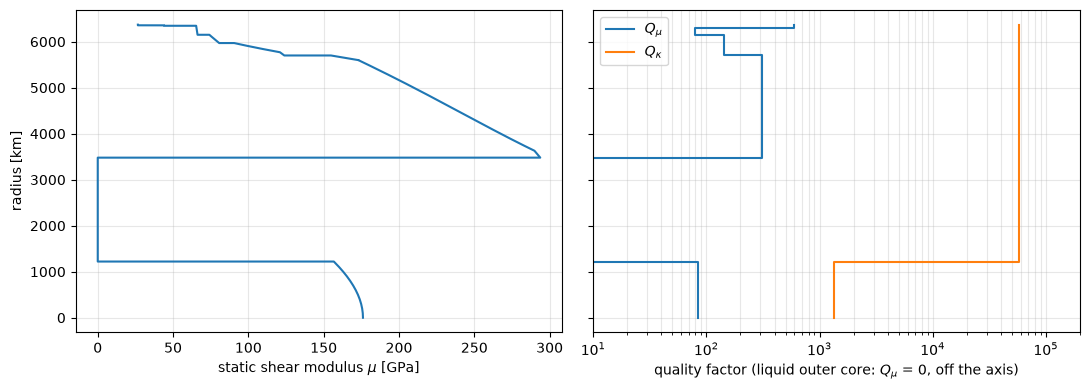

In [3]:
prem = data_file.load_radial_data(worldpack.resolve_data_file("PREM.csv"))
radius_km = prem["radius_m"] / 1.0e3
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
axes[0].plot(prem["shear_modulus_pa"] / 1.0e9, radius_km)
axes[0].set_xlabel(r"static shear modulus $\mu$ [GPa]")
axes[1].plot(prem["shear_q"], radius_km, label=r"$Q_\mu$")
axes[1].set_xscale("log")
axes[1].set_xlim(10.0, 2.0e5)
axes[1].plot(prem["bulk_q"], radius_km, label=r"$Q_\kappa$")
axes[1].set_xlabel("quality factor (liquid outer core: $Q_\\mu$ = 0, off the axis)")
axes[0].set_ylabel("radius [km]")
axes[1].legend()
for ax in axes:
    ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()

changes = np.flatnonzero(np.diff(prem["shear_q"]) != 0.0) + 1
for start, stop in zip(np.concatenate(([0], changes)), np.concatenate((changes, [radius_km.size]))):
    print(f"  {radius_km[start]:7.1f} to {radius_km[stop - 1]:7.1f} km:  Q_mu = {prem['shear_q'][start]:6.1f}")

## PREM With Its Own Attenuation

`earth_prem_q` is `earth_prem` with three more keys. Every solid layer then takes the `seismic_q` rheology with the world's settings, and its quality factors ride in its viscosity arrays, which is where `seismic_q` reads them:

```toml
data_file = "PREM.csv"
q_provided = true                                  # use the profile's q_mu and q_kappa columns
q_reference_frequency_rad_s = 6.283185307179586    # 2 pi rad/s: PREM's 1 s reference period
q_frequency_exponent = 0.0                         # the seismic Q at every frequency
```

In [4]:
elastic = build_world("earth_prem")
attenuating = build_world("earth_prem_q")
for world in (elastic, attenuating):
    world.solve_eos(G_to_use=G, verbose=False)

print({key: value for key, value in attenuating.portable_config.items() if key.startswith("q_")})
live = attenuating.get_config_dict()["layers"]
for layer, (name, table) in zip(attenuating, live.items()):
    print(f"  {name}: solid = {layer.is_solid!s:5s}  shear_rheology = {table.get('shear_rheology')}")


def k2(world, frequency):
    result = world.solve_love_numbers(frequency=frequency, degree_l=2)
    assert result["success"], result["message"]
    return complex(world.love_number_k)


def lag_degrees(love):
    # TidalPy's Love numbers lag the forcing with a negative imaginary part.
    return -math.degrees(math.atan2(love.imag, love.real))


print(f"\n{'forcing':>22s} {'elastic k2':>11s} {'attenuating k2':>22s} {'lag [deg]':>10s}")
for label, period in (("1 s (reference)", 1.0), ("M2, 12.42 h", 12.4206012 * HOUR), ("K1, 23.93 h", 23.9345 * HOUR),
                      ("Mf, 13.66 d", 13.6608 * DAY), ("Chandler, 433 d", 433.0 * DAY)):
    frequency = 2.0 * math.pi / period
    k_elastic, k_attenuating = k2(elastic, frequency), k2(attenuating, frequency)
    print(f"{label:>22s} {k_elastic.real:11.5f} {k_attenuating.real:10.5f} {k_attenuating.imag:+.2e}i "
          f"{lag_degrees(k_attenuating):10.4f}")

{'q_provided': True, 'q_reference_frequency_rad_s': 6.283185307179586, 'q_frequency_exponent': 0.0}
  layer_0: solid = True   shear_rheology = {'model': 'seismic_q', 'reference_frequency_rad_s': 6.283185307179586, 'q_frequency_exponent': 0.0}
  layer_1: solid = False  shear_rheology = None
  layer_2: solid = True   shear_rheology = {'model': 'seismic_q', 'reference_frequency_rad_s': 6.283185307179586, 'q_frequency_exponent': 0.0}

               forcing  elastic k2         attenuating k2  lag [deg]
       1 s (reference)     0.29836    0.29835 -6.08e-04i     0.1167
           M2, 12.42 h     0.29836    0.30246 -6.11e-04i     0.1158
           K1, 23.93 h     0.29836    0.30270 -6.12e-04i     0.1157
           Mf, 13.66 d     0.29836    0.30370 -6.12e-04i     0.1155
       Chandler, 433 d     0.29836    0.30500 -6.14e-04i     0.1153


At 1 s the attenuating world's $k_2$ has the elastic PREM's real part, since PREM's moduli are its 1 s moduli. Only the small loss is new. Toward longer periods the dispersion softens the mantle, and $k_2$ grows from 0.298 to 0.302 at M2 and 0.305 at the Chandler period. With $a = 0$ the lag hardly changes with period, because $Q$ does not.

## How Must Q Scale With Frequency?

Ray, Eanes, and Lemoine (2001) measured the lag of Earth's M2 body tide from satellite tracking and altimetry at $0.20^\circ \pm 0.05^\circ$, an effective $Q$ near 280. PREM's own $Q$ carried unchanged to 12 hours ($a = 0$) gives 0.116°, a little over half that. Sweeping the exponent shows what PREM needs.

M2 lag at a = 0: 0.116 deg (effective Q 495)
a matching the measured lag 0.20 deg: 0.051 (0.15 to 0.25 deg: a = 0.024 to 0.072)


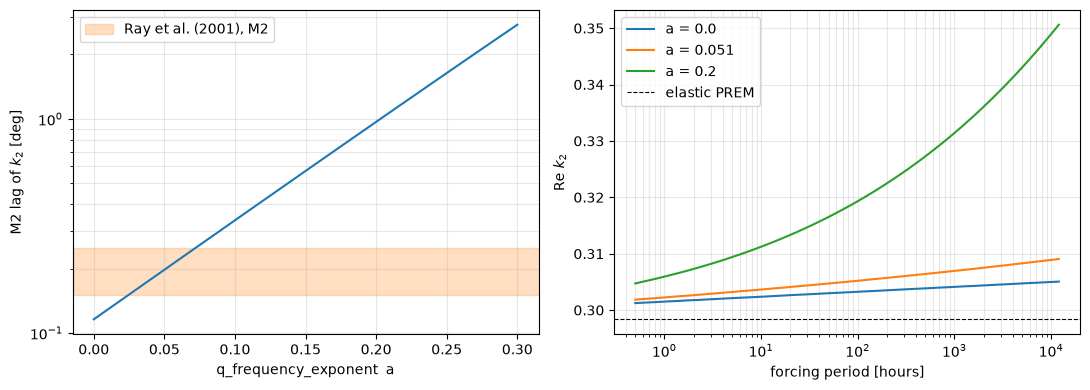

In [5]:
base = copy.deepcopy(attenuating.portable_config)


def prem_q(exponent):
    world = build_world(dict(base, q_frequency_exponent=float(exponent)))
    world.solve_eos(G_to_use=G, verbose=False)
    return world


exponents = np.linspace(0.0, 0.3, 31)
lags = np.array([lag_degrees(k2(prem_q(exponent), M2)) for exponent in exponents])
matched = np.interp([0.15, 0.20, 0.25], lags, exponents)
print(f"M2 lag at a = 0: {lags[0]:.3f} deg (effective Q {1.0 / math.tan(math.radians(lags[0])):.0f})")
print(f"a matching the measured lag 0.20 deg: {matched[1]:.3f} (0.15 to 0.25 deg: a = {matched[0]:.3f} to {matched[2]:.3f})")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(exponents, lags)
axes[0].axhspan(0.15, 0.25, color="C1", alpha=0.25, label="Ray et al. (2001), M2")
axes[0].set_xlabel("q_frequency_exponent  a")
axes[0].set_ylabel("M2 lag of $k_2$ [deg]")
axes[0].set_yscale("log")
axes[0].legend()
periods = np.logspace(math.log10(0.5 * HOUR), math.log10(500.0 * DAY), 40)
for exponent in (0.0, round(float(matched[1]), 3), 0.2):
    world = prem_q(exponent)
    loves = np.array([k2(world, 2.0 * math.pi / period) for period in periods])
    axes[1].semilogx(periods / HOUR, loves.real, label=f"a = {exponent}")
elastic_k2 = k2(elastic, M2).real
axes[1].axhline(elastic_k2, color="k", lw=0.8, ls="--", label="elastic PREM")
axes[1].set_xlabel("forcing period [hours]")
axes[1].set_ylabel("Re $k_2$")
axes[1].legend()
for ax in axes:
    ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()

An exponent near 0.05 reproduces the measured lag. That is at the low end of the 0.1 to 0.3 laboratory and geodetic estimates for the mantle, and it shows what the choice of $a$ carries. Take the match as illustrative:

* PREM's $Q$ is a one-dimensional average, and the measured lag belongs to the real, laterally varying Earth after an ocean-tide correction.
* A single exponent across four and a half decades of frequency is itself an assumption.
* The reference frequency sets where the extrapolation starts, and it is a separate setting (`q_reference_frequency_rad_s`). Some anelastic Earth models quote their $Q$ at 200 s instead of 1 s.

## Layer by Layer

The world's two settings seed every solid layer's `seismic_q` table. A layer table that names `seismic_q` itself overrides them for that layer. Below, the mantle's $Q$ falls with $a = 0.2$ while the inner core keeps its seismic $Q$, and the mantle's bulk response is set to elastic, ignoring $Q_\kappa$. A layer table may not name another rheology, give a viscosity, or name a material type: each would put a viscosity where `seismic_q` reads a quality factor, and the build refuses it.

In [6]:
config = copy.deepcopy(base)
config["layers"] = {
    "mantle": {"layer_index": 2,
               "shear_rheology": {"model": "seismic_q", "q_frequency_exponent": 0.2},
               "bulk_rheology": {"model": "elastic"}},
}
layered = build_world(config)
layered.solve_eos(G_to_use=G, verbose=False)
for name, table in layered.get_config_dict()["layers"].items():
    print(f"  {name}: shear {table.get('shear_rheology')}  bulk {table.get('bulk_rheology')}")
print(f"M2 k2 = {k2(layered, M2):.5f}")

try:
    build_world(dict(base, layers={"mantle": {"layer_index": 2, "shear_rheology": {"model": "maxwell"}}}))
except ValueError as error:
    print("\nRefused:", error)

  layer_0: shear {'model': 'seismic_q', 'reference_frequency_rad_s': 6.283185307179586, 'q_frequency_exponent': 0.0}  bulk {'model': 'seismic_q', 'reference_frequency_rad_s': 6.283185307179586, 'q_frequency_exponent': 0.0}
  layer_1: shear None  bulk None
  mantle: shear {'model': 'seismic_q', 'reference_frequency_rad_s': 6.283185307179586, 'q_frequency_exponent': 0.2}  bulk {'model': 'elastic'}
M2 k2 = 0.31185-0.00527j

Refused: World 'Earth-PREM-Q', layer 'mantle': its shear_rheology names the 'maxwell' rheology, but with 'q_provided = true' the layer's loss arrays hold quality factors, which only the 'seismic_q' rheology reads.


## Notes

* **Where Q lives.** A layer's quality factors ride in its viscosity arrays, so its `get_shear_viscosity` returns $Q$, not a viscosity. The `seismic_q` rheology reads them as $Q$ on any layer, so attach it only where that slot holds one.
* **Zero frequency** is taken as no forcing: the modulus, with no loss. A constant-$Q$ lag does not shrink toward zero forcing frequency as a viscous one does, so near synchronous rotation a torque computed from it jumps sign rather than passing through zero. Heating is unaffected, since it scales with the frequency.
* **Bulk loss** comes from `q_kappa` when the profile gives it. A layer table can set an `elastic` bulk rheology to ignore it.
* **Stale data copy.** A data file copied into the TidalPy data directory by an older install is used ahead of the packaged one. A pre-Q copy of `PREM.csv` there makes `earth_prem_q` fail with a message naming the file. Delete the copy, or call `TidalPy.Structures.install_worldpack(force=True)`.

### References

* Dziewonski, A. M., and Anderson, D. L. (1981). Preliminary reference Earth model. *Physics of the Earth and Planetary Interiors*, 25, 297-356.
* Kanamori, H., and Anderson, D. L. (1977). Importance of physical dispersion in surface wave and free oscillation problems: Review. *Reviews of Geophysics*, 15, 105-112.
* Wahr, J., and Bergen, Z. (1986). The effects of mantle anelasticity on nutations, earth tides, and tidal variations in rotation rate. *Geophysical Journal of the Royal Astronomical Society*, 87, 633-668.
* Ray, R. D., Eanes, R. J., and Lemoine, F. G. (2001). Constraints on energy dissipation in the Earth's body tide from satellite tracking and altimetry. *Geophysical Journal International*, 144, 471-480.